# Orientação Política Através do Discurso
Como Posicionar Falas de Deputados em Meio às Orientações Partidárias?

---

João Pedro Rodrigues Vieira - 10403595


## 0. Preparação do Ambiente

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import re
import nltk
import torch
import string
import uuid
import unicodedata
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.stem import RSLPStemmer
from nltk.corpus import stopwords
from transformers import set_seed
from sklearn.pipeline import Pipeline
from nltk.tokenize import word_tokenize
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import Normalizer
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import balanced_accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict, cross_validate

## 1. Datasets e Transformação dos Dados

### 1.1. Notícias que descrevem o posicionamento do partido com relação ao tema

In [4]:
news_path = "content/noticia_partidos.jsonl"

news_df = pd.read_json(news_path, lines=True)
print('Linhas x Colunas:', news_df.shape)
news_df.head()

Linhas x Colunas: (1061, 7)


,titulo,texto_cru,data_publicacao,link,keywords_encontradas,fonte_descoberta,partido
0,Câmara dos Deputados aprova aumento da pena de...,"Nesta última quarta-feira (11), a Câmara dos D...",2024-09-12,https://avante70.org.br/noticias/camara-dos-de...,"[arma, arma de fogo]",wp-api,AVANTE
1,Manaus reforça liderança nacional em segurança...,"O prefeito de Manaus, David Almeida (Avante), ...",2025-12-04,https://avante70.org.br/noticias/manaus-reforc...,"[arma, pistola, municao, calibre, arma de fogo]",wp-api,AVANTE
2,Deputada federal Greyce Elias é relatora de PL...,"A Câmara dos Deputados aprovou, nesta terça-fe...",2021-04-14,https://avante70.org.br/noticias/deputada-fede...,"[armas, porte de armas]",wp-api,AVANTE
3,Projeto da deputada Greyce Elias permite uso d...,A deputada federal Greyce Elias (Avante/MG) ap...,2021-07-01,https://avante70.org.br/noticias/projeto-da-de...,"[armas, armas de fogo]",wp-api,AVANTE
4,Carlos Cavalcante cobra maior policiamento,Carlos Cavalcante relata casos de violência e ...,2009-11-12,https://avante70.org.br/noticias/carlos-cavalc...,"[arma, arma de fogo]",wp-api,AVANTE


### 1.2. Base de discursos da câmara dos deputados

In [5]:
discourses_path = "content/firearm-carry-speeches-2014-2026.jsonl"

discourse_df = pd.read_json(discourses_path, lines=True)
print('Linhas x Colunas:', discourse_df.shape)
discourse_df.head()

Linhas x Colunas: (256, 20)


,id,event_id,deputy_id,deputy_name,party,political_spectrum,ideological_stance,state,legislature_id,speech_type,keywords,transcript,summary,start_date,end_date,major_claim,micro_arguments,topic_consistency,is_argumentative,stance
0,a660973a-7e8f-422e-ac12-3d85e2ca27aa,35538,167614,Severino Ninho,PSB,Centro-esquerda,Progressista,PE,54,ORIENTAÇÃO DE BANCADA,"PL 6565/2013, PROJETO DE LEI, CONCESSÃO, PORTE...",O SR. SEVERINO NINHO (PSB-PE. Pela ordem. Sem ...,Orientação de bancada favorável do PSB ao Proj...,2014-03-26T14:00,2014-03-26T20:28,o PSB também vota a favor do projeto,[{'claim': 'alertando nossos queridos guardas ...,TOPIC,True,PRO
1,9bf5cbca-b734-421d-852e-54d48b21079d,35538,4931,Izalci,PSDB,Centro,Neutro,DF,54,ORIENTAÇÃO DE BANCADA,"PL 6565/2013, PROJETO DE LEI, CONCESSÃO, PORTE...",O SR. IZALCI (PSDB-DF. Pela ordem. Sem revisão...,Orientação de bancada favorável do PSDB ao Pro...,2014-03-26T14:00,2014-03-26T20:28,o PSDB vota pela aprovação do projeto,[{'claim': 'Os agentes e guardas prisionais pr...,TOPIC,True,PRO
2,1152aead-d96e-475b-8b09-bcbf9010d313,35538,73466,Rubens Bueno,PPS,,,PR,54,PELA ORDEM,"PL 6565/2013, PROJETO DE LEI, CONCESSÃO, PORTE...",O SR. RUBENS BUENO (PPS-PR. Pela Ordem. Sem re...,"Ponderações sobre o Projeto de Lei nº 6.565, d...",2014-03-26T14:00,2014-03-26T20:28,O PPS vota favoravelmente.,[{'claim': 'Nós também estamos de acordo com q...,TOPIC,True,PRO
3,4962cc8d-5fad-43a4-abdf-1c443171f23e,35538,73433,Arlindo Chinaglia,PT,Esquerda,Progressista,SP,54,PELA ORDEM,"PL 6565/2013, PROJETO DE LEI, CONCESSÃO, PORTE...",O SR. ARLINDO CHINAGLIA (PT-SP. Pela ordem. Se...,Solicitação à bancada do PT de retirada de req...,2014-03-26T14:00,2014-03-26T20:28,nós caminharemos para a votação de acordo com ...,"[{'claim': 'eu quero, então, propor e pedir à ...",TOPIC,True,NEUTRAL
4,1a79dbf5-a338-4deb-8ee2-646cc7b19b87,35538,74848,Jandira Feghali,PCDOB,Esquerda,Progressista,RJ,54,ORIENTAÇÃO DE BANCADA,"PL 6565/2013, PROJETO DE LEI, CONCESSÃO, PORTE...",A SRA. JANDIRA FEGHALI (PCdoB-RJ. Pela ordem. ...,Orientação de bancada favorável do PC do B ao ...,2014-03-26T14:00,2014-03-26T20:28,"O PCdoB vota ""sim"" ao projeto.",[{'claim': 'entendemos que é correto colocar n...,TOPIC,True,PRO


### 1.3. Metadados
A EDA começa conhecendo a estrutura: quantas linhas/colunas, tipos e valores faltantes.


In [6]:
news_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   titulo                1061 non-null   str   
 1   texto_cru             1061 non-null   str   
 2   data_publicacao       1061 non-null   str   
 3   link                  1061 non-null   str   
 4   keywords_encontradas  1061 non-null   object
 5   fonte_descoberta      1061 non-null   str   
 6   partido               1061 non-null   str   
dtypes: object(1), str(6)
memory usage: 58.2+ KB


In [7]:
discourse_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  256 non-null    str   
 1   event_id            256 non-null    int64 
 2   deputy_id           256 non-null    int64 
 3   deputy_name         256 non-null    str   
 4   party               256 non-null    str   
 5   political_spectrum  256 non-null    str   
 6   ideological_stance  256 non-null    str   
 7   state               256 non-null    str   
 8   legislature_id      256 non-null    int64 
 9   speech_type         256 non-null    str   
 10  keywords            256 non-null    str   
 11  transcript          256 non-null    str   
 12  summary             256 non-null    str   
 13  start_date          256 non-null    str   
 14  end_date            256 non-null    str   
 15  major_claim         256 non-null    str   
 16  micro_arguments     256 non-null    o

In [8]:
print("Valores nulos por coluna em news_df:")
news_nulls = news_df.isna().sum().rename("quantidade_nulos")
print(news_nulls.to_frame())

print("\nValores nulos por coluna em discourse_df:")
discourse_nulls = discourse_df.isna().sum().rename("quantidade_nulos")
print(discourse_nulls.to_frame())

Valores nulos por coluna em news_df:
                      quantidade_nulos
titulo                               0
texto_cru                            0
data_publicacao                      0
link                                 0
keywords_encontradas                 0
fonte_descoberta                     0
partido                              0

Valores nulos por coluna em discourse_df:
                    quantidade_nulos
id                                 0
event_id                           0
deputy_id                          0
deputy_name                        0
party                              0
political_spectrum                 0
ideological_stance                 0
state                              0
legislature_id                     0
speech_type                        0
keywords                           0
transcript                         0
summary                            0
start_date                         0
end_date                           0
major_claim     

### 1.4. Obtendo argumentos

In [9]:
def get_argument(adu) -> str:
    parts = [adu["major_claim"]]

    for micro_argument in adu["micro_arguments"]:
        parts.append(micro_argument["claim"])

        for premise in micro_argument["premises"]:
            if premise.strip().upper() == "[IMPLICIT]":
                continue
            parts.append(premise)

    return " ".join(parts)

In [10]:
discourse_df["argument"] = discourse_df.apply(get_argument, axis=1);
discourse_df["argument"][0]

'o PSB também vota a favor do projeto alertando nossos queridos guardas e agentes penitenciários para a responsabilidade que se deve ter com uma arma na mão e também dentro de casa pelo risco aos familiares É preciso que quem recebe o porte de arma receba um treinamento sério O PSB se preocupa muito com essa questão de termos cada vez mais armas nas ruas É necessário que os próprios agentes de segurança prisional busquem esse treinamento para que a arma não se volte contra eles e não prejudique a sociedade'

### 1.5. Auditoria de qualidade dos dados

Antes da modelagem, são verificadas possíveis duplicações de discursos e
argumentos. Essa etapa procura identificar casos em que textos iguais ou
praticamente iguais aparecem mais de uma vez na base, inclusive associados
a eventos distintos, o que poderia favorecer artificialmente o desempenho
dos modelos durante a validação.

In [11]:
# Cópia apenas para a auditoria; o dataframe original ainda não será alterado
audit_df = discourse_df.copy()

# Normalização mínima para detectar textos iguais mesmo com diferenças
# irrelevantes de maiúsculas/minúsculas ou espaços.
audit_df["transcript_norm"] = (
    audit_df["transcript"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

audit_df["argument_norm"] = (
    audit_df["argument"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Ignora textos vazios na análise de duplicatas
valid_transcript = audit_df["transcript_norm"].ne("")
valid_argument = audit_df["argument_norm"].ne("")

duplicated_transcript = (
    valid_transcript
    & audit_df["transcript_norm"].duplicated(keep=False)
)

duplicated_argument = (
    valid_argument
    & audit_df["argument_norm"].duplicated(keep=False)
)

print("=== AUDITORIA DE DUPLICATAS ===")
print(f"Total de registros: {len(audit_df)}")

print("\nTranscrições:")
print(
    f"  Registros envolvidos em duplicatas: "
    f"{duplicated_transcript.sum()}"
)
print(
    f"  Textos duplicados distintos: "
    f"{audit_df.loc[duplicated_transcript, 'transcript_norm'].nunique()}"
)

print("\nArgumentos:")
print(
    f"  Registros envolvidos em duplicatas: "
    f"{duplicated_argument.sum()}"
)
print(
    f"  Argumentos duplicados distintos: "
    f"{audit_df.loc[duplicated_argument, 'argument_norm'].nunique()}"
)

=== AUDITORIA DE DUPLICATAS ===
Total de registros: 256

Transcrições:
  Registros envolvidos em duplicatas: 104
  Textos duplicados distintos: 52

Argumentos:
  Registros envolvidos em duplicatas: 8
  Argumentos duplicados distintos: 4


In [12]:
duplicate_event_analysis = (
    audit_df.loc[duplicated_transcript]
    .groupby("transcript_norm")
    .agg(
        occurrences=("id", "size"),
        different_events=("event_id", "nunique"),
        event_ids=("event_id", lambda x: list(pd.unique(x))),
        parties=("party", lambda x: list(pd.unique(x))),
        deputies=("deputy_name", lambda x: list(pd.unique(x))),
    )
    .sort_values(
        ["different_events", "occurrences"],
        ascending=False
    )
)

cross_event_duplicates = duplicate_event_analysis[
    duplicate_event_analysis["different_events"] > 1
]

print(
    "Grupos de transcrições duplicadas presentes "
    f"em eventos diferentes: {len(cross_event_duplicates)}"
)

cross_event_duplicates.head(10)

Grupos de transcrições duplicadas presentes em eventos diferentes: 50


,occurrences,different_events,event_ids,parties,deputies
transcript_norm,,,,,
"a sra. alice portugal (pcdob - ba. sem revisão da oradora.) - sr. presidente, sras. e srs. deputados, esta é uma matéria sensível. eu esperava que o plenário, de fato, pudesse se debruçar hoje sobre um novo texto, após o longo processo negocial que se deu semana passada, quando se chegou à conclusão de que o projeto iria se resumir aos caçadores, atiradores e colecionadores - cacs. hoje, estamos vendo que há pequenas modificações no projeto, mas se mantém o elemento crucial de armar o brasil. policiais poderão ter dez armas, parte delas armas longas desse tipo - a deputada fernanda já mostrou aqui anteriormente. (exibe imagem.) o cidadão comum poderá ter seis armas automáticas, inclusive dessa natureza - seis armas! (exibe imagem.) quem nós queremos armar no brasil? os cacs poderão ter 14 armas por ano - por ano! que arsenal é esse que se está montando? nós vamos armar milícias? nós vamos armar quadrilhas? se o policial tiver dez armas em casa, a casa dele será um ponto de assalto. aqueles que dizem defender os policiais estão deixando suas famílias reféns dos bandidos, que irão buscar armas nas casas dos policiais. o projeto mantém incongruências como essa do art. 2º. após fazer um relato sobre 2 anos para legalizar armas que foram compradas de forma ilegal ou desconhecida, ele muda, propõe um ""ou"", para que o cidadão que tem uma arma ilegal apenas apresente uma declaração firmada, na qual constem as características da arma, a numeração legível e a sua condição de proprietário, ficando dispensado do pagamento de taxas e do cumprimento das demais exigências. é uma autoanistia para armas ilegais, para armas não legalizadas. só penso que isso serve para pagar financiamentos de campanha que já foram realizados, como, por exemplo, para o ministro onyx lorenzoni, através da taurus. o gráfico do crescimento das ações da taurus, pelo simples anúncio da votação desse projeto, está... (desligamento automático do microfone.) o sr. genecias noronha (solidariedade - ce. pela ordem. sem revisão do orador.) - sr. presidente, o deputado genecias noronha votou com o partido na última votação. o sr. delegado waldir (psl - go. pela ordem. sem revisão do orador.) - sr. presidente, o deputado delegado waldir votou com o partido na última votação. o sr. presidente (isnaldo bulhões jr. bloco/mdb - al) - peço a v.exa. que conclua, deputada. a sra. alice portugal (pcdob - ba) - vou concluir, presidente, com a gentileza de v.exa. quero dizer que esse requerimento de adiamento interessa para que possamos refletir melhor e dizer ""não"" a esse projeto, garantindo o que hoje regula o armamento no brasil, fruto do plebiscito e fruto de todo o estatuto do desarmamento aprovado por esta casa. muito obrigada.",2,2,"[58491, 58528]",[PCDOB],[Alice Portugal]
"a sra. benedita da silva (pt - rj. pela ordem. sem revisão da oradora.) - sr. presidente, nós ouvimos há pouco um deputado falar sobre derramamento de sangue. em hebreus está escrito que, sem derramamento de sangue, não haverá redenção, mas se refere àqueles que deram sua vida e derramaram seu sangue, como jesus cristo assim o fez, para a redenção da humanidade. ele associa isso ao fato de estarmos dizendo que somos contra o porte de armas. se ele quer usar mal um versículo bíblico, eu digo a ele que, revestidas as armaduras de deus, as armas trazem mais homicídios para este país. e quem está morrendo neste contexto? a população que está armada, que deveria estar dando segurança para o nosso país.",2,2,"[58491, 58528]",[PT],[Benedita da Silva]
"a sra. erika kokay (pt - df. pela ordem. sem revisão da oradora.) - a liberação das armas vai ajudar fundamentalmente as milícias. eu ouvi falar muito em cidadão de bem. quem é cidadão de bem? queiroz? queiroz é cidadão de bem? ronnie lessa é cidadão de bem? quem são os cidadãos de bem de quem se fala aqui? tenta-se prender dilma rousseff, que nem investigada é. isso é um absurdo! nós t

In [13]:
# Agrupamento do espectro político em três classes,
# seguindo a definição usada na etapa supervisionada.
spectrum_map_audit = {
    "Esquerda": "Esquerda",
    "Centro-esquerda": "Esquerda",
    "Centro": "Centro",
    "Centro-direita": "Direita",
    "Direita": "Direita",
    "Extrema-direita": "Direita",
    "Extrema- direita": "Direita",
}

audit_df["spectrum_3"] = audit_df["political_spectrum"].map(spectrum_map_audit)

supervised_audit_df = audit_df[
    audit_df["spectrum_3"].notna()
].copy()

dup_transcript_supervised = (
    supervised_audit_df["transcript_norm"].ne("")
    & supervised_audit_df["transcript_norm"].duplicated(keep=False)
)

dup_argument_supervised = (
    supervised_audit_df["argument_norm"].ne("")
    & supervised_audit_df["argument_norm"].duplicated(keep=False)
)

cross_event_supervised = (
    supervised_audit_df.loc[dup_transcript_supervised]
    .groupby("transcript_norm")
    .agg(
        occurrences=("id", "size"),
        different_events=("event_id", "nunique"),
        event_ids=("event_id", lambda x: list(pd.unique(x))),
        classes=("spectrum_3", lambda x: list(pd.unique(x))),
    )
)

cross_event_supervised = cross_event_supervised[
    cross_event_supervised["different_events"] > 1
]

print("=== AUDITORIA DA BASE SUPERVISIONADA ===")
print(f"Amostras supervisionadas: {len(supervised_audit_df)}")

print("\nTranscrições:")
print(
    f"  Registros envolvidos em duplicatas: "
    f"{dup_transcript_supervised.sum()}"
)
print(
    f"  Textos duplicados distintos: "
    f"{supervised_audit_df.loc[dup_transcript_supervised, 'transcript_norm'].nunique()}"
)

print("\nArgumentos:")
print(
    f"  Registros envolvidos em duplicatas: "
    f"{dup_argument_supervised.sum()}"
)
print(
    f"  Argumentos duplicados distintos: "
    f"{supervised_audit_df.loc[dup_argument_supervised, 'argument_norm'].nunique()}"
)

print(
    "\nGrupos de transcrições duplicadas presentes "
    f"em eventos diferentes: {len(cross_event_supervised)}"
)

=== AUDITORIA DA BASE SUPERVISIONADA ===
Amostras supervisionadas: 207

Transcrições:
  Registros envolvidos em duplicatas: 78
  Textos duplicados distintos: 39

Argumentos:
  Registros envolvidos em duplicatas: 8
  Argumentos duplicados distintos: 4

Grupos de transcrições duplicadas presentes em eventos diferentes: 37


In [14]:
import re

def mentions_own_party(row):
    party = str(row["party"]).strip()

    if not party or party.lower() == "nan":
        return False

    argument = str(row["argument"])

    pattern = rf"(?<!\w){re.escape(party)}(?!\w)"

    return bool(
        re.search(
            pattern,
            argument,
            flags=re.IGNORECASE
        )
    )


supervised_audit_df["mentions_own_party"] = (
    supervised_audit_df.apply(
        mentions_own_party,
        axis=1
    )
)

n_party_mentions = supervised_audit_df[
    "mentions_own_party"
].sum()

pct_party_mentions = (
    100 * n_party_mentions / len(supervised_audit_df)
)

print("=== POSSÍVEL LEAKAGE POR IDENTIDADE PARTIDÁRIA ===")
print(
    f"Argumentos que mencionam explicitamente o próprio partido: "
    f"{n_party_mentions}/{len(supervised_audit_df)} "
    f"({pct_party_mentions:.1f}%)"
)

supervised_audit_df.loc[
    supervised_audit_df["mentions_own_party"],
    [
        "deputy_name",
        "party",
        "spectrum_3",
        "argument"
    ]
].head(10)

=== POSSÍVEL LEAKAGE POR IDENTIDADE PARTIDÁRIA ===
Argumentos que mencionam explicitamente o próprio partido: 45/207 (21.7%)


,deputy_name,party,spectrum_3,argument
0,Severino Ninho,PSB,Esquerda,o PSB também vota a favor do projeto alertando...
1,Izalci,PSDB,Centro,o PSDB vota pela aprovação do projeto Os agent...
3,Arlindo Chinaglia,PT,Esquerda,nós caminharemos para a votação de acordo com ...
4,Jandira Feghali,PCDOB,Esquerda,"O PCdoB vota ""sim"" ao projeto. entendemos que ..."
7,Vieira da Cunha,PDT,Esquerda,"o PDT vota favoravelmente Nós estamos, na verd..."
39,Daniel Almeida,PCDOB,Esquerda,o PCdoB quer encaminhar o requerimento no sent...
40,Marcelo Freixo,PSOL,Esquerda,estamos defendendo a retirada de pauta do cham...
44,Subtenente Gonzaga,PDT,Esquerda,a flexibilização do controle da comercializaçã...
47,Daniel Coelho,CIDADANIA,Esquerda,"o Cidadania encaminha ""obstrução"" Praticamente..."
69,Célio Moura,PT,Esquerda,"Não poderíamos, de forma nenhuma, hoje votar e..."


#### Agrupamento para prevenção de vazamento entre folds

Como algumas transcrições idênticas aparecem associadas a diferentes `event_id`,
a validação agrupada apenas pelo evento pode permitir que conteúdos repetidos
apareçam simultaneamente nos conjuntos de treino e teste.

Para evitar esse problema sem descartar observações, será criado um identificador
de grupo que mantém juntos tanto registros pertencentes ao mesmo evento quanto
registros associados a transcrições duplicadas.

In [15]:
# Union-Find simples para unir eventos conectados por transcrições duplicadas
class UnionFind:
    def __init__(self):
        self.parent = {}

    def find(self, x):
        if x not in self.parent:
            self.parent[x] = x

        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])

        return self.parent[x]

    def union(self, a, b):
        root_a = self.find(a)
        root_b = self.find(b)

        if root_a != root_b:
            self.parent[root_b] = root_a


uf = UnionFind()

# Primeiro, cada event_id existe como um grupo próprio.
for event_id in supervised_audit_df["event_id"].unique():
    uf.find(event_id)

# Depois, eventos ligados pela mesma transcrição são unidos.
duplicate_groups = (
    supervised_audit_df[
        supervised_audit_df["transcript_norm"].ne("")
    ]
    .groupby("transcript_norm")["event_id"]
    .apply(lambda x: list(pd.unique(x)))
)

for event_ids in duplicate_groups:
    if len(event_ids) > 1:
        first_event = event_ids[0]

        for other_event in event_ids[1:]:
            uf.union(first_event, other_event)

# Identificador final de agrupamento
supervised_audit_df["leakage_group"] = (
    supervised_audit_df["event_id"]
    .map(uf.find)
)

print("=== GRUPOS PARA VALIDAÇÃO ANTI-LEAKAGE ===")
print(
    f"event_id distintos: "
    f"{supervised_audit_df['event_id'].nunique()}"
)

print(
    f"grupos finais após unir eventos conectados por duplicatas: "
    f"{supervised_audit_df['leakage_group'].nunique()}"
)

=== GRUPOS PARA VALIDAÇÃO ANTI-LEAKAGE ===
event_id distintos: 37
grupos finais após unir eventos conectados por duplicatas: 35


In [16]:
from sklearn.model_selection import StratifiedGroupKFold

cv_leakage_check = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

y_audit = supervised_audit_df["spectrum_3"].to_numpy()
groups_audit = supervised_audit_df["leakage_group"].to_numpy()

leakage_found = False

for fold, (train_idx, test_idx) in enumerate(
    cv_leakage_check.split(
        supervised_audit_df,
        y_audit,
        groups=groups_audit
    ),
    start=1
):
    train_transcripts = set(
        supervised_audit_df.iloc[train_idx]["transcript_norm"]
    )

    test_transcripts = set(
        supervised_audit_df.iloc[test_idx]["transcript_norm"]
    )

    overlap = (
        train_transcripts
        & test_transcripts
        - {""}
    )

    print(
        f"Fold {fold}: "
        f"{len(overlap)} transcrições repetidas "
        f"entre treino e teste"
    )

    if overlap:
        leakage_found = True


if not leakage_found:
    print(
        "\nResultado: nenhuma transcrição idêntica "
        "aparece simultaneamente em treino e teste."
    )

Fold 1: 0 transcrições repetidas entre treino e teste
Fold 2: 0 transcrições repetidas entre treino e teste
Fold 3: 0 transcrições repetidas entre treino e teste
Fold 4: 0 transcrições repetidas entre treino e teste
Fold 5: 0 transcrições repetidas entre treino e teste

Resultado: nenhuma transcrição idêntica aparece simultaneamente em treino e teste.


#### Mascaramento da identidade partidária

Uma parcela dos argumentos contém explicitamente a sigla do partido do
parlamentar. Como o espectro político utilizado como rótulo está associado
ao partido, essa informação pode funcionar como um atalho para o modelo.

Para avaliar esse efeito, será criada uma versão alternativa dos argumentos
na qual a identificação explícita do próprio partido é substituída por um
marcador neutro. Os textos originais são preservados para comparação.

In [17]:
def mask_own_party(row):
    party = str(row["party"]).strip()
    argument = str(row["argument"])

    if not party or party.lower() == "nan":
        return argument

    # Delimitadores que evitam substituir a sigla
    # quando ela fizer parte de outra palavra.
    pattern = rf"(?<!\w){re.escape(party)}(?!\w)"

    return re.sub(
        pattern,
        "[PARTY]",
        argument,
        flags=re.IGNORECASE,
    )


supervised_audit_df["argument_masked"] = (
    supervised_audit_df.apply(
        mask_own_party,
        axis=1,
    )
)

In [18]:
mask_examples = supervised_audit_df[
    supervised_audit_df["mentions_own_party"]
][
    [
        "party",
        "spectrum_3",
        "argument",
        "argument_masked",
    ]
].head(10)

mask_examples

,party,spectrum_3,argument,argument_masked
0,PSB,Esquerda,o PSB também vota a favor do projeto alertando...,o [PARTY] também vota a favor do projeto alert...
1,PSDB,Centro,o PSDB vota pela aprovação do projeto Os agent...,o [PARTY] vota pela aprovação do projeto Os ag...
3,PT,Esquerda,nós caminharemos para a votação de acordo com ...,nós caminharemos para a votação de acordo com ...
4,PCDOB,Esquerda,"O PCdoB vota ""sim"" ao projeto. entendemos que ...","O [PARTY] vota ""sim"" ao projeto. entendemos qu..."
7,PDT,Esquerda,"o PDT vota favoravelmente Nós estamos, na verd...","o [PARTY] vota favoravelmente Nós estamos, na ..."
39,PCDOB,Esquerda,o PCdoB quer encaminhar o requerimento no sent...,o [PARTY] quer encaminhar o requerimento no se...
40,PSOL,Esquerda,estamos defendendo a retirada de pauta do cham...,estamos defendendo a retirada de pauta do cham...
44,PDT,Esquerda,a flexibilização do controle da comercializaçã...,a flexibilização do controle da comercializaçã...
47,CIDADANIA,Esquerda,"o Cidadania encaminha ""obstrução"" Praticamente...","o [PARTY] encaminha ""obstrução"" Praticamente e..."
69,PT,Esquerda,"Não poderíamos, de forma nenhuma, hoje votar e...","Não poderíamos, de forma nenhuma, hoje votar e..."


In [19]:
def still_mentions_own_party(row):
    party = str(row["party"]).strip()

    if not party or party.lower() == "nan":
        return False

    pattern = rf"(?<!\w){re.escape(party)}(?!\w)"

    return bool(
        re.search(
            pattern,
            str(row["argument_masked"]),
            flags=re.IGNORECASE,
        )
    )


remaining_party_mentions = (
    supervised_audit_df.apply(
        still_mentions_own_party,
        axis=1,
    )
)

print("=== VERIFICAÇÃO DO PARTY MASKING ===")

print(
    "Menções explícitas antes do mascaramento:",
    supervised_audit_df["mentions_own_party"].sum(),
)

print(
    "Menções explícitas após o mascaramento:",
    remaining_party_mentions.sum(),
)

=== VERIFICAÇÃO DO PARTY MASKING ===
Menções explícitas antes do mascaramento: 45
Menções explícitas após o mascaramento: 0


### 1.5. Padronizando siglas partidárias nas notícias e atribuindo espectro político a cada uma delas

In [20]:
news_to_discourse_party = {
    "PARTIDO COMUNISTA BRASILEIRO": "PCB",
    "PARTIDO COMUNISTA DO BRASIL": "PCDOB",
    "PARTIDO DA SOCIAL DEMOCRACIA BRASILEIRA": "PSDB",
    "PARTIDO SOCIALISTA BRASILEIRO": "PSB",
    "PARTIDO VERDE": "PV",
    "REPUBLICANOS": "REPUBLICAN",
    "PARTIDO SOCIALISMO E LIBERDADE": "PSOL",
    "PARTIDO DOS TRABALHADORES": "PT",
    "PARTIDO DEMOCRÁTICO TRABALHISTA": "PDT",
    "PARTIDO SOCIAL DEMOCRÁTICO": "PSD",
    "PARTIDO NOVO": "NOVO",
    "CIDADANIA": "CIDADANIA",
    "MOVIMENTO DEMOCRÁTICO BRASILEIRO": "MDB",
    "PARTIDO LIBERAL": "PL",
    "UNIDADE POPULAR": "UP",
    "PARTIDO DA CAUSA OPERÁRIA": "PCO",
    "SOLIDARIEDADE": "SOLIDARIED",
    "AVANTE": "AVANTE",
    "PROGRESSISTAS": "PP",
    "DEMOCRACIA CRISTÃ": "DC",
    "REDE SUSTENTABILIDADE": "REDE",
}

news_df["partido"] = news_df["partido"].replace(news_to_discourse_party)

In [21]:
party_spectrum = {
    "AVANTE": "Centro",
    "CIDADANIA": "Centro-esquerda",
    "DC": "Centro-direita",
    "MDB": "Centro",
    "NOVO": "Direita",
    "PCB": "Extrema-esquerda",
    "PCDOB": "Esquerda",
    "PCO": "Extrema-esquerda",
    "PDT": "Centro-esquerda",
    "PL": "Centro-direita",
    "PP": "Centro-direita",
    "PSB": "Centro-esquerda",
    "PSD": "Centro",
    "PSDB": "Centro",
    "PSOL": "Esquerda",
    "PT": "Esquerda",
    "PV": "Centro-esquerda",
    "REDE": "Centro-esquerda",
    "REPUBLICAN": "Direita",
    "SOLIDARIED": "Centro-esquerda",
    "UP": "Extrema-esquerda",
}

news_df["espectro_politico"] = (
    news_df["partido"]
    .map(party_spectrum)
)

print(news_df[["partido", "espectro_politico"]].drop_duplicates().sort_values("partido"))
print("Notícias sem espectro:", news_df["espectro_politico"].isna().sum())

         partido espectro_politico
0         AVANTE            Centro
7      CIDADANIA   Centro-esquerda
29            DC    Centro-direita
30           MDB            Centro
595         NOVO           Direita
46           PCB  Extrema-esquerda
183        PCDOB          Esquerda
309          PCO  Extrema-esquerda
442          PDT   Centro-esquerda
577           PL    Centro-direita
951           PP    Centro-direita
703          PSB   Centro-esquerda
793          PSD            Centro
316         PSDB            Centro
625         PSOL          Esquerda
506           PT          Esquerda
855           PV   Centro-esquerda
954         REDE   Centro-esquerda
955   REPUBLICAN           Direita
1039  SOLIDARIED   Centro-esquerda
1044          UP  Extrema-esquerda
Notícias sem espectro: 0


## 2. Análise Exploratória (EDA)


### 2.1. Tamanho do texto em caracteres


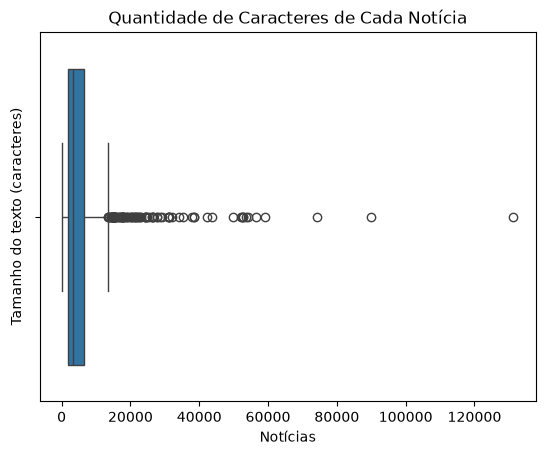

In [22]:
news_size = news_df['texto_cru'].fillna('').str.len()
sns.boxplot(news_df, x = news_size)
plt.title('Quantidade de Caracteres de Cada Notícia')
plt.xlabel("Notícias")
plt.ylabel('Tamanho do texto (caracteres)')
plt.show()

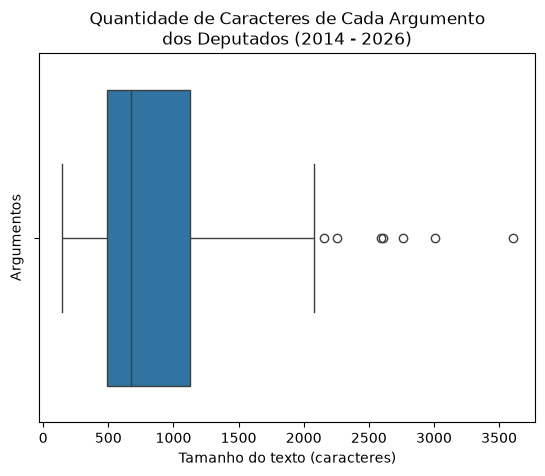

In [23]:
argument_size = discourse_df['argument'].str.len()
sns.boxplot(discourse_df, x = argument_size)
plt.title("Quantidade de Caracteres de Cada Argumento\ndos Deputados (2014 - 2026)")
plt.xlabel("Tamanho do texto (caracteres)")
plt.ylabel("Argumentos")
plt.show()

### 2.2. Um olhar sobre as palavras: quais termos melhor identificam o texto?

#### 2.2.1 TF-IDF

In [24]:
nltk.download("stopwords", quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download("rslp", quiet=True)

True

In [25]:
def preprocessing_text(text, stopwords_pt, stemmer = None) -> str:
    if not isinstance(text, str):
        return "";

    # NFC garante que palavras como "é" e "e" (escrita errada)
    # sejam entendidas da mesma forma
    text = unicodedata.normalize("NFC", text).lower()

    # Filtragem de links e e-mails
    text = re.sub(r"https?://\S+|www\.\S+", " ", text);
    text = re.sub(r"\S+@\S+", " ", text);

    # remoção de pontuações e caracteres especiais
    # espaços e acentuações são mantidas
    text = re.sub(r"[^\w\s]|[\d_]", " ", text);

    tokens = [t for t in text.split() if len(t) > 2 and t not in stopwords_pt]

    if stemmer is not None:
        tokens = [stemmer.stem(t) for t in tokens]

    return " ".join(tokens)

In [26]:
def tf_idf(
        text: pd.Series,
        stemming: bool = False,
        stopwords_extras: list | None = None,
        ngram_range: tuple = (1, 1),
        min_df: int | float = 1,
        max_df: int | float = 1.0
):
        sw = set(stopwords.words("portuguese"));

        if stopwords_extras:
                sw.update(stopwords_extras);

        sw = {unicodedata.normalize("NFC", p.lower()) for p in sw };

        stemmer = RSLPStemmer() if stemming else None;

        clean_texts = text.apply(lambda t: preprocessing_text(t, sw, stemmer));

        vectorizer = TfidfVectorizer(
                ngram_range = ngram_range,
                min_df = min_df,
                max_df = max_df,
                # \w com (?u) reconhece letras acentuadas
                token_pattern = r"(?u)\b\w+\b",
                # já é o padrão, mas aqui se faz explícito
                strip_accents=None
        );

        matrix = vectorizer.fit_transform(clean_texts);

        df_tfidf = pd.DataFrame(
                matrix.toarray(),
                index = text.index,
                columns = vectorizer.get_feature_names_out(),
        );

        ranking = df_tfidf.mean(axis = 0).sort_values(ascending = False);
        return df_tfidf, ranking, vectorizer

In [27]:
news_tfidf, news_tfidf_ranking, news_vectorizer = tf_idf(news_df["texto_cru"])

In [28]:
print(news_tfidf_ranking.head(10))

armas         0.038750
segurança     0.026282
governo       0.023771
brasil        0.023265
presidente    0.021753
fogo          0.021715
violência     0.021434
bolsonaro     0.021118
contra        0.020856
federal       0.020739
dtype: float64


In [29]:
discourse_tfidf, discourse_tfidf_ranking, discourse_vectorizer = tf_idf(discourse_df["argument"])

In [30]:
discourse_tfidf_ranking.head(10)

armas        0.054578
arma         0.042059
segurança    0.037055
projeto      0.036094
governo      0.027231
cidadão      0.026332
direito      0.025401
porte        0.024742
pública      0.024679
país         0.024455
dtype: float64

#### 2.2.2. Termos discriminantes por espectro político

Além da importância média dos termos no corpus completo, é útil verificar
quais palavras e expressões possuem maior importância relativa em cada faixa
do espectro político.

Para isso, o TF-IDF é calculado sobre o mesmo vocabulário para todas as
classes, e a média de cada termo em uma classe é comparada à média observada
nas demais classes. Dessa forma, destacam-se termos mais característicos de
Esquerda, Centro e Direita.

In [31]:
# Stopwords em português, preservando termos de negação
# que podem carregar informação semântica importante.
stopwords_pt_discriminative = set(stopwords.words("portuguese"))

for word in ["não", "sem", "contra"]:
    stopwords_pt_discriminative.discard(word)


def clean_for_tfidf(text):
    return preprocessing_text(
        text,
        stopwords_pt_discriminative,
        stemmer=None,
    )


supervised_audit_df["argument_clean"] = (
    supervised_audit_df["argument"]
    .fillna("")
    .apply(clean_for_tfidf)
)

vectorizer_disc = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    sublinear_tf=True,
    token_pattern=r"(?u)\b\w+\b",
    strip_accents=None,
)

X_tfidf_disc = vectorizer_disc.fit_transform(
    supervised_audit_df["argument_clean"]
)

feature_names_disc = np.array(
    vectorizer_disc.get_feature_names_out()
)

print("Matriz TF-IDF:", X_tfidf_disc.shape)
print("Número de termos/unigramas-bigramas:", len(feature_names_disc))

Matriz TF-IDF: (207, 1519)
Número de termos/unigramas-bigramas: 1519


In [32]:
# Ordem fixa das classes para manter a saída organizada
classes_order = ["Esquerda", "Centro", "Direita"]

# Limpeza do texto mascarado usando a função já definida anteriormente
supervised_audit_df["argument_masked_clean"] = (
    supervised_audit_df["argument_masked"]
    .fillna("")
    .apply(clean_for_tfidf)
)

# TF-IDF com unigramas e bigramas
vectorizer_masked = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    sublinear_tf=True,
    token_pattern=r"(?u)\b\w+\b",
    strip_accents=None,
)

X_tfidf_masked = vectorizer_masked.fit_transform(
    supervised_audit_df["argument_masked_clean"]
)

feature_names_masked = np.array(
    vectorizer_masked.get_feature_names_out()
)

print("Matriz TF-IDF mascarada:", X_tfidf_masked.shape)
print(
    "Número de termos/unigramas-bigramas:",
    len(feature_names_masked)
)

# Cálculo dos termos mais discriminantes por classe
masked_discriminative_terms = {}

for political_class in classes_order:

    class_mask = (
        supervised_audit_df["spectrum_3"].to_numpy()
        == political_class
    )

    other_mask = ~class_mask

    class_mean = np.asarray(
        X_tfidf_masked[class_mask].mean(axis=0)
    ).ravel()

    other_mean = np.asarray(
        X_tfidf_masked[other_mask].mean(axis=0)
    ).ravel()

    # Quanto maior a diferença, mais característico
    # o termo é daquela classe em relação às demais
    difference = class_mean - other_mean

    top_indices = np.argsort(difference)[::-1][:15]

    masked_discriminative_terms[political_class] = pd.DataFrame({
        "termo": feature_names_masked[top_indices],
        "score_discriminante": difference[top_indices],
        "tfidf_classe": class_mean[top_indices],
        "tfidf_outras": other_mean[top_indices],
    })

# Exibição das três tabelas
for political_class in classes_order:
    print(
        f"\n=== {political_class.upper()} — PARTY MASKED ==="
    )
    display(masked_discriminative_terms[political_class])

Matriz TF-IDF mascarada: (207, 1518)
Número de termos/unigramas-bigramas: 1518

=== ESQUERDA — PARTY MASKED ===


,termo,score_discriminante,tfidf_classe,tfidf_outras
0,armas,0.036961,0.062408,0.025448
1,violência,0.032622,0.037710,0.005088
2,sociedade,0.020828,0.028071,0.007243
3,obstrução,0.019270,0.019270,0.000000
4,contra,0.018944,0.034141,0.015197
5,porte armas,0.017225,0.018112,0.000887
6,número,0.016589,0.020165,0.003576
7,mortes,0.016116,0.019579,0.003463
8,população,0.015484,0.027315,0.011831
9,significa,0.015253,0.015253,0.000000



=== CENTRO — PARTY MASKED ===


,termo,score_discriminante,tfidf_classe,tfidf_outras
0,aprovação,0.038022,0.041374,0.003353
1,grande,0.035318,0.044542,0.009224
2,voto,0.033388,0.048416,0.015028
3,guardas,0.031826,0.038187,0.006361
4,bem,0.031790,0.047714,0.015924
5,existem,0.029279,0.031161,0.001882
6,insegurança,0.027172,0.030036,0.002864
7,seguro,0.025480,0.028636,0.003155
8,possível,0.024629,0.027833,0.003204
9,atiradores colecionadores,0.024178,0.026170,0.001991



=== DIREITA — PARTY MASKED ===


,termo,score_discriminante,tfidf_classe,tfidf_outras
0,atiradores,0.021047,0.024688,0.003641
1,defesa,0.018892,0.026388,0.007495
2,esquerda,0.018384,0.018384,0.000000
3,crime,0.017482,0.027175,0.009693
4,lula,0.016443,0.020299,0.003856
5,direito,0.016380,0.033855,0.017474
6,governo,0.015879,0.037742,0.021863
7,cacs,0.015176,0.031446,0.016271
8,propriedade,0.015066,0.017508,0.002442
9,instrumento,0.014465,0.014465,0.000000


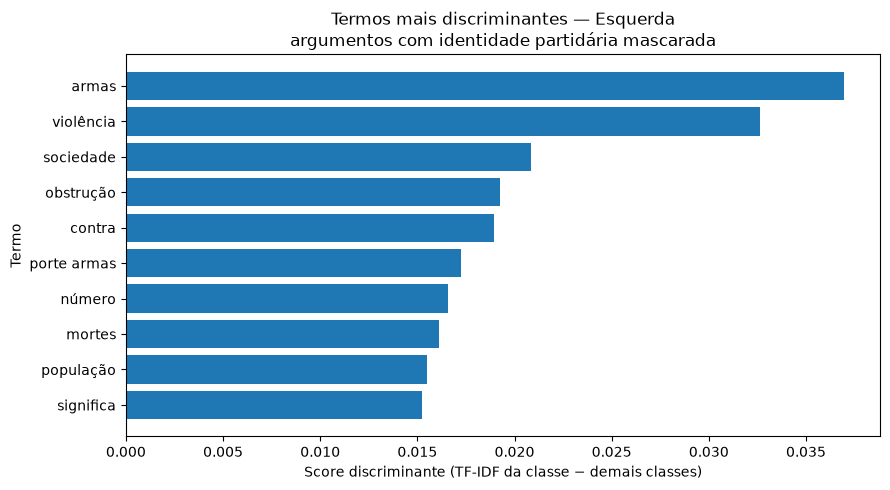

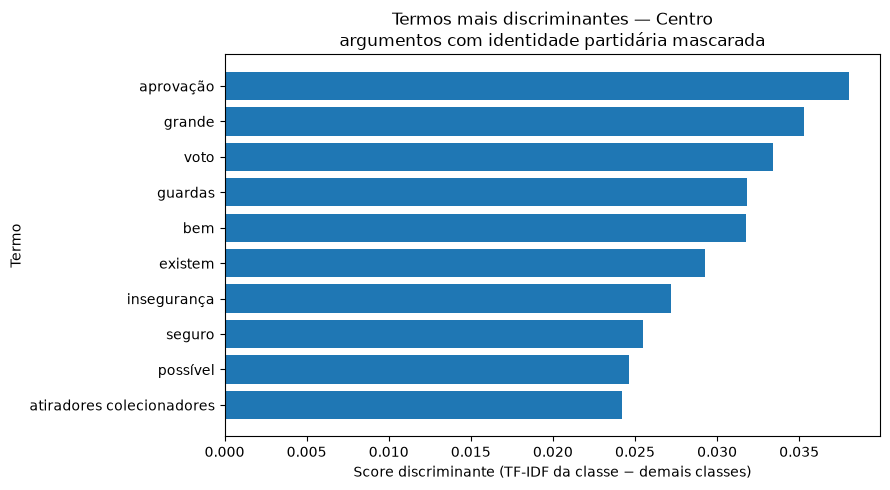

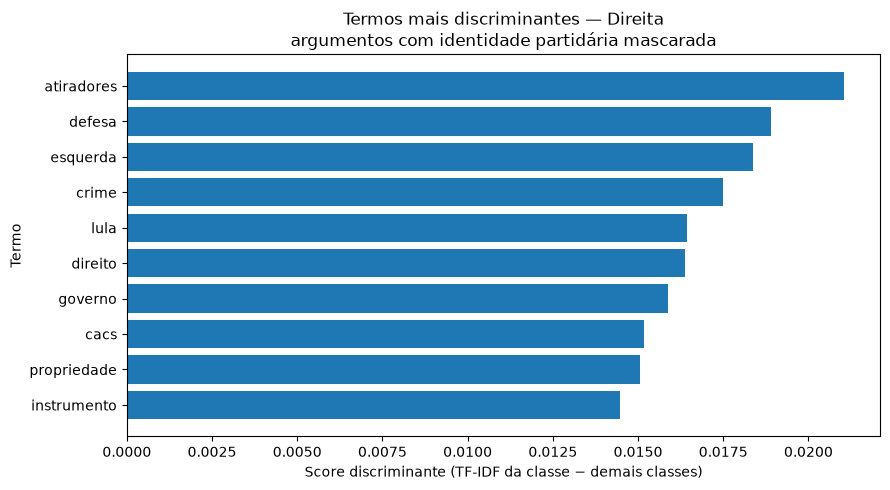

In [33]:
def plot_discriminative_terms(
    results_dict,
    top_n=10,
    title_suffix="Party-masked"
):
    for political_class in classes_order:

        plot_df = (
            results_dict[political_class]
            .head(top_n)
            .sort_values(
                "score_discriminante",
                ascending=True
            )
        )

        plt.figure(figsize=(9, 5))

        plt.barh(
            plot_df["termo"],
            plot_df["score_discriminante"]
        )

        plt.xlabel("Score discriminante (TF-IDF da classe − demais classes)")
        plt.ylabel("Termo")

        plt.title(
            f"Termos mais discriminantes — "
            f"{political_class}\n{title_suffix}"
        )

        plt.tight_layout()
        plt.show()


plot_discriminative_terms(
    masked_discriminative_terms,
    top_n=10,
    title_suffix="argumentos com identidade partidária mascarada"
)

**Interpretação.** Após o mascaramento das siglas partidárias, ainda são
observadas diferenças lexicais entre as três faixas do espectro. No conjunto
analisado, os argumentos classificados como Esquerda apresentam maior destaque
relativo para termos associados a armas, violência e consequências sociais;
os classificados como Direita destacam termos relacionados a atiradores,
defesa, direito, propriedade e CACs; enquanto a classe Centro apresenta maior
presença relativa de termos institucionais e procedimentais.

Esses resultados devem ser interpretados como padrões do corpus analisado,
restrito ao tema de posse e porte de armas, e não como caracterizações gerais
das diferentes orientações políticas.

### 2.3. Distribuição partidária

#### 2.3.1. Notícias

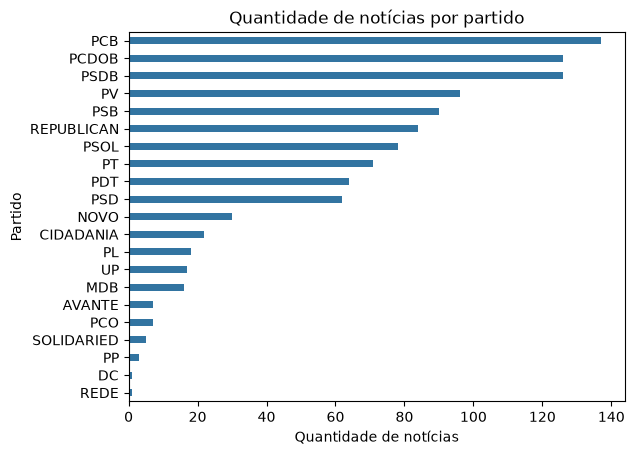

In [34]:
party_order = news_df["partido"].value_counts().index

sns.countplot(
    data=news_df,
    y="partido",
    order=party_order,
    gap=0.5,
)
plt.xlabel("Quantidade de notícias")
plt.ylabel("Partido")
plt.title("Quantidade de notícias por partido")
plt.show()

#### 2.3.2. Discursos

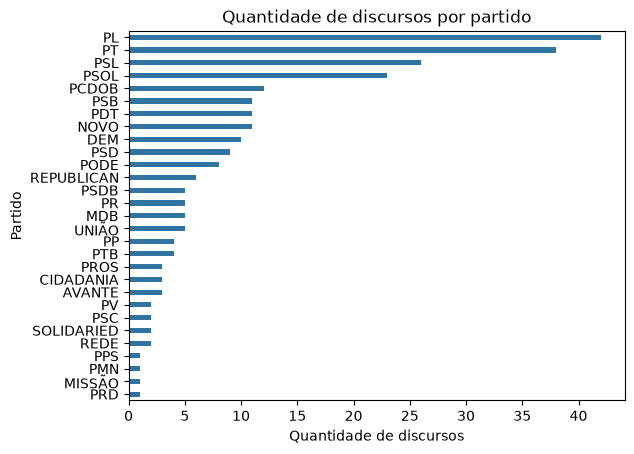

In [35]:
party_order = discourse_df["party"].value_counts().index

sns.countplot(
    data=discourse_df,
    y="party",
    order=party_order,
    gap=0.5,
)
plt.xlabel("Quantidade de discursos")
plt.ylabel("Partido")
plt.title("Quantidade de discursos por partido")
plt.show()

### 2.4. Distribuição por espectro político

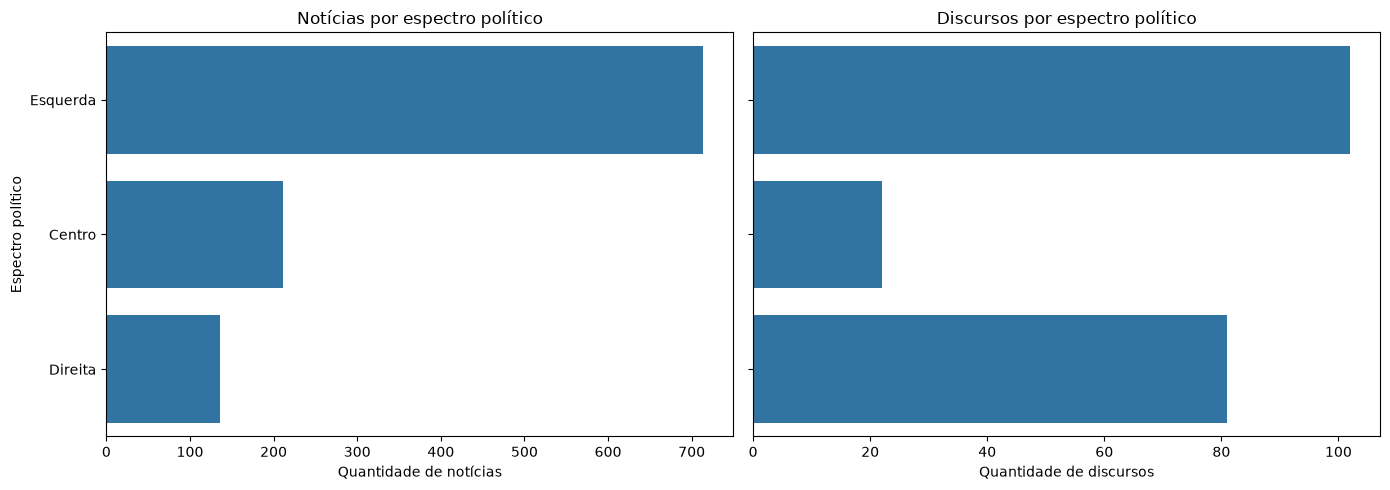

In [36]:
spectrum_order = [
    "Esquerda",
    "Centro",
    "Direita",
]

spectrum_map = {
    "Extrema-esquerda": "Esquerda",
    "Esquerda": "Esquerda",
    "Centro-esquerda": "Esquerda",
    "Centro": "Centro",
    "Centro-direita": "Direita",
    "Direita": "Direita",
    "Extrema-direita": "Direita",
}

discourse_df["political_spectrum"] = discourse_df["political_spectrum"].replace(spectrum_map)
news_df["espectro_politico"] = news_df["espectro_politico"].replace(spectrum_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.countplot(
    data=news_df,
    y="espectro_politico",
    order=spectrum_order,
    ax=axes[0],
)
axes[0].set_title("Notícias por espectro político")
axes[0].set_xlabel("Quantidade de notícias")
axes[0].set_ylabel("Espectro político")

sns.countplot(
    data=discourse_df,
    y="political_spectrum",
    order=spectrum_order,
    ax=axes[1],
)
axes[1].set_title("Discursos por espectro político")
axes[1].set_xlabel("Quantidade de discursos")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 3. Geração de Embeddings

### Execução dos embeddings

Os embeddings utilizados nos experimentos principais já estão armazenados
no repositório em `content/argument_embeddings.pt` e
`content/news_embeddings.pt`.

A regeneração completa com BERTimbau Large exige mais memória do que o
ambiente padrão do GitHub Codespaces disponibiliza. Por isso, os artefatos
pré-calculados são carregados diretamente durante a modelagem.

O código de geração é mantido no notebook para fins de reprodutibilidade,
mas não precisa ser executado em ambientes com memória limitada.

> **Observação de execução:** os embeddings utilizados na modelagem estão
> armazenados no repositório. A regeneração com BERTimbau Large pode exigir
> mais memória do que ambientes padrão do GitHub Codespaces disponibilizam.
> Para reproduzir somente a análise e a classificação, os arquivos `.pt`
> pré-calculados podem ser carregados diretamente.

In [37]:
set_seed(34)

In [38]:
device = "cpu" # torch.device("cuda" if torch.cuda.is_available() else "cpu");
print(f"Hardware utilizado: {device}");

Hardware utilizado: cpu


In [39]:
model = "neuralmind/bert-large-portuguese-cased";
tokenizer = AutoTokenizer.from_pretrained(model);
bertimbau = AutoModel.from_pretrained(model).to(device);
max_length = bertimbau.config.max_position_embeddings;

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 5872.00it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-large-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 3.1. Tokenização e obtenção dos embeddings

In [40]:
def tokenize(texts: list[str], max_length, device):
    return tokenizer(texts, padding=True, truncation=True, return_tensors="pt", max_length=max_length).to(device);

In [1]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state;
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float();

    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9);

In [ ]:
import gc

def generate_embeddings_batched(
    texts,
    tokenizer,
    model,
    device,
    max_length,
    batch_size=4
):
    """
    Gera embeddings em pequenos lotes para evitar estouro de memória.
    """
    all_embeddings = []

    model.eval()

    for start in range(0, len(texts), batch_size):
        end = min(start + batch_size, len(texts))
        batch_texts = texts[start:end]

        batch_tokens = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors="pt",
            max_length=max_length,
        ).to(device)

        with torch.inference_mode():
            batch_output = model(**batch_tokens)

            batch_embeddings = mean_pooling(
                batch_output,
                batch_tokens["attention_mask"],
            )

        all_embeddings.append(batch_embeddings.cpu())

        # Libera memória antes do próximo lote
        del batch_tokens
        del batch_output
        del batch_embeddings
        gc.collect()

        print(
            f"Processados {end}/{len(texts)} textos",
            end="\r"
        )

    print()

    return torch.cat(all_embeddings, dim=0)

: 

#### 3.1.1. Discursos

In [ ]:
arguments = (
    discourse_df["argument"]
    .fillna("")
    .tolist()
)

argument_embeddings = generate_embeddings_batched(
    texts=arguments,
    tokenizer=tokenizer,
    model=bertimbau,
    device=device,
    max_length=max_length,
    batch_size=4,
)

argument_array = argument_embeddings.numpy()

print(
    "Embeddings dos argumentos:",
    tuple(argument_embeddings.shape)
)

NameError: name 'discourse_df' is not defined

#### 3.1.2. Notícias

In [ ]:
news_df["news_id"] = [str(uuid.uuid4()) for _ in range(len(news_df))]

print(f"IDs únicos atribuídos: {news_df['news_id'].nunique()}")
news_df[["news_id", "titulo", "partido"]].head()

IDs únicos atribuídos: 1061


,news_id,titulo,partido
0,2193abee-004a-446e-a69c-412212f59a27,Câmara dos Deputados aprova aumento da pena de...,AVANTE
1,d65920f0-a088-4c0b-bfa3-d857b843894d,Manaus reforça liderança nacional em segurança...,AVANTE
2,09be0d10-f811-4315-bd19-bd3a4e95fc28,Deputada federal Greyce Elias é relatora de PL...,AVANTE
3,95a43a15-b3e5-4367-96d0-edc99db5def7,Projeto da deputada Greyce Elias permite uso d...,AVANTE
4,445e7c78-82bc-4fbb-99b4-b6d13f9b6ab2,Carlos Cavalcante cobra maior policiamento,AVANTE


In [ ]:
news_df["news_text"] = (
    news_df["titulo"].str.strip() + ". " + news_df["texto_cru"].str.strip()
).str.strip()

print(f"Notícias carregadas: {len(news_df)}")
news_df[["titulo", "partido", "news_text"]].head(2)

Notícias carregadas: 1061


,titulo,partido,news_text
0,Câmara dos Deputados aprova aumento da pena de...,AVANTE,Câmara dos Deputados aprova aumento da pena de...
1,Manaus reforça liderança nacional em segurança...,AVANTE,Manaus reforça liderança nacional em segurança...


In [ ]:
news_texts = news_df["news_text"].tolist()
news_embeddings_batches = []
batch_size = 8

with torch.no_grad():
    for start in range(0, len(news_texts), batch_size):
        batch_texts = news_texts[start:start + batch_size]
        batch_tokens = tokenize(batch_texts, max_length, device)
        batch_output = bertimbau(**batch_tokens)
        batch_embeddings = mean_pooling(
            batch_output,
            batch_tokens["attention_mask"]
        )
        news_embeddings_batches.append(batch_embeddings.cpu())

news_embeddings = torch.cat(news_embeddings_batches, dim=0)
print(f"Embeddings das notícias: {tuple(news_embeddings.shape)}")

Embeddings das notícias: (1061, 1024)


In [ ]:
news_embedding_artifact = {
    "embeddings": news_embeddings,
    "ids": news_df["news_id"].tolist(),
    "political_spectrum": news_df["espectro_politico"].tolist(),
}

torch.save(news_embedding_artifact, "content/news_embeddings.pt")
print("Embeddings salvos em content/news_embeddings.pt")

Embeddings salvos em content/news_embeddings.pt


## 4. Classificação do espectro político

A primeira tarefa supervisionada será classificar os discursos em três faixas.

- **Esquerda**: Extrema-Esquerda, Esquerda e Centro-esquerda
- **Centro**: Centro
- **Direita**: Centro-direita, Direita e Extrema-direita

O baseline será uma aplicação do modelo Linear SVC sob os dados coletados de TF-IDF. A comparação será feita a partir do uso do mesmo modelo sob o emprego dos embeddings previamente coletados. A divisão entre cada embedding está no próprio id que identifica a notícia ou o discurso, sendo que cada embedding também carrega o espectro político do partido ao qual o texto está associado.

A ideia central está em averiguar se, para um mesmo tema (neste caso, posse e porte de armas de fogo), os argumentos estão alinhados ao espectro político ao qual dizem pertencer. Isto é, se o argumento que é identificado como próximo a uma notícia está próximo de um posicionamento cujo espectro político é o mesmo do parlamentar que discursou.

In [42]:
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    classification_report,
)

In [48]:
def load_pt(path):
    data = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    embeddings = data["embeddings"]

    if torch.is_tensor(embeddings):
        embeddings = embeddings.float().numpy()
    else:
        embeddings = np.asarray(
            embeddings,
            dtype=np.float32
        )

    ids = np.array(data["ids"])

    political_spectrum = data["political_spectrum"]

    if torch.is_tensor(political_spectrum):
        political_spectrum = political_spectrum.tolist()
    else:
        political_spectrum = list(political_spectrum)

    political_spectrum = np.array([
        str(value).strip()
        for value in political_spectrum
    ])

    if not (
        len(embeddings)
        == len(ids)
        == len(political_spectrum)
    ):
        raise ValueError(
            "Tamanhos diferentes: "
            f"embeddings={len(embeddings)}, "
            f"ids={len(ids)}, "
            f"espectros={len(political_spectrum)}"
        )

    if len(set(ids)) != len(ids):
        raise ValueError(
            "Há IDs duplicados no arquivo."
        )

    return (
        embeddings,
        ids,
        political_spectrum
    )

In [49]:
emb_arg, ids_arg, esp_arg = load_pt(
    "content/argument_embeddings.pt"
)

emb_news, ids_news, esp_news = load_pt(
    "content/news_embeddings.pt"
)

print(
    "Embeddings dos argumentos:",
    emb_arg.shape
)

print(
    "Embeddings das notícias:",
    emb_news.shape
)

Embeddings dos argumentos: (256, 1024)
Embeddings das notícias: (1061, 1024)


In [45]:
spectrum_map_model = {
    "Esquerda": "Esquerda",
    "Centro-esquerda": "Esquerda",

    "Centro": "Centro",

    "Centro-direita": "Direita",
    "Direita": "Direita",
    "Extrema-direita": "Direita",
    "Extrema- direita": "Direita",
}

esp_arg_3 = np.array([
    spectrum_map_model.get(value)
    for value in esp_arg
])

valid_arg_mask = np.array([
    value is not None
    for value in esp_arg_3
])

print(
    "Embeddings totais:",
    len(esp_arg_3)
)

print(
    "Amostras com espectro válido:",
    valid_arg_mask.sum()
)

print("\nDistribuição das três classes:")

print(
    pd.Series(
        esp_arg_3[valid_arg_mask]
    ).value_counts()
)

Embeddings totais: 256
Amostras com espectro válido: 207

Distribuição das três classes:
Esquerda    102
Direita      83
Centro       22
Name: count, dtype: int64


In [46]:
# ============================================================
# Preparação dos dados para validação anti-leakage
# ============================================================

# Recarrega apenas os metadados necessários dos discursos
model_metadata = pd.read_json(
    "content/firearm-carry-speeches-2014-2026.jsonl",
    lines=True,
)

# Coloca os registros exatamente na mesma ordem dos embeddings
model_metadata = (
    model_metadata
    .set_index("id")
    .reindex(ids_arg)
    .reset_index()
)

if model_metadata["id"].isna().any():
    raise ValueError(
        "Algum embedding não pôde ser associado ao respectivo discurso."
    )

# Normalização mínima das transcrições para localizar duplicatas
model_metadata["transcript_norm"] = (
    model_metadata["transcript"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)


# Union-Find para unir eventos conectados por transcrições repetidas
class UnionFind:
    def __init__(self):
        self.parent = {}

    def find(self, x):
        if x not in self.parent:
            self.parent[x] = x

        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])

        return self.parent[x]

    def union(self, a, b):
        root_a = self.find(a)
        root_b = self.find(b)

        if root_a != root_b:
            self.parent[root_b] = root_a


uf = UnionFind()

# Considera apenas as 207 amostras supervisionadas
supervised_metadata = (
    model_metadata.loc[valid_arg_mask]
    .copy()
    .reset_index(drop=True)
)

for event_id in supervised_metadata["event_id"].unique():
    uf.find(event_id)

duplicate_event_groups = (
    supervised_metadata[
        supervised_metadata["transcript_norm"].ne("")
    ]
    .groupby("transcript_norm")["event_id"]
    .apply(lambda values: list(pd.unique(values)))
)

for event_ids in duplicate_event_groups:
    if len(event_ids) > 1:
        first_event = event_ids[0]

        for other_event in event_ids[1:]:
            uf.union(first_event, other_event)

supervised_metadata["leakage_group"] = (
    supervised_metadata["event_id"]
    .map(uf.find)
)

# Matrizes finais para modelagem
X_embeddings = emb_arg[valid_arg_mask]
y = esp_arg_3[valid_arg_mask]
groups = supervised_metadata["leakage_group"].to_numpy()

print("=== DADOS PARA MODELAGEM ===")
print("X:", X_embeddings.shape)
print("y:", y.shape)

print(
    "event_id originais:",
    supervised_metadata["event_id"].nunique()
)

print(
    "grupos anti-leakage:",
    supervised_metadata["leakage_group"].nunique()
)

print("\nDistribuição:")
print(pd.Series(y).value_counts())

=== DADOS PARA MODELAGEM ===
X: (207, 1024)
y: (207,)
event_id originais: 37
grupos anti-leakage: 35

Distribuição:
Esquerda    102
Direita      83
Centro       22
Name: count, dtype: int64


In [47]:
cv_check = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

print("=== VERIFICAÇÃO DOS FOLDS ===")

for fold, (train_idx, test_idx) in enumerate(
    cv_check.split(
        X_embeddings,
        y,
        groups=groups,
    ),
    start=1,
):
    train_transcripts = set(
        supervised_metadata.iloc[train_idx]["transcript_norm"]
    )

    test_transcripts = set(
        supervised_metadata.iloc[test_idx]["transcript_norm"]
    )

    overlap = (
        train_transcripts
        & test_transcripts
        - {""}
    )

    train_classes = pd.Series(y[train_idx]).value_counts()
    test_classes = pd.Series(y[test_idx]).value_counts()

    print(f"\nFold {fold}")
    print(
        f"  treino={len(train_idx)} | "
        f"teste={len(test_idx)}"
    )

    print(
        f"  transcrições repetidas treino/teste: "
        f"{len(overlap)}"
    )

    print(
        "  classes no teste:",
        test_classes.to_dict()
    )

=== VERIFICAÇÃO DOS FOLDS ===

Fold 1
  treino=134 | teste=73
  transcrições repetidas treino/teste: 0
  classes no teste: {'Esquerda': 49, 'Direita': 16, 'Centro': 8}

Fold 2
  treino=168 | teste=39
  transcrições repetidas treino/teste: 0
  classes no teste: {'Esquerda': 20, 'Direita': 16, 'Centro': 3}

Fold 3
  treino=175 | teste=32
  transcrições repetidas treino/teste: 0
  classes no teste: {'Direita': 17, 'Esquerda': 11, 'Centro': 4}

Fold 4
  treino=176 | teste=31
  transcrições repetidas treino/teste: 0
  classes no teste: {'Direita': 17, 'Esquerda': 10, 'Centro': 4}

Fold 5
  treino=175 | teste=32
  transcrições repetidas treino/teste: 0
  classes no teste: {'Direita': 17, 'Esquerda': 12, 'Centro': 3}


### 4.1. LinearSVC com validação aninhada e grupos anti-leakage

O hiperparâmetro `C` do LinearSVC é selecionado apenas nos folds internos
da validação. Os folds externos são utilizados exclusivamente para avaliação.

Além disso, a divisão respeita os grupos anti-leakage definidos anteriormente,
impedindo que transcrições idênticas apareçam simultaneamente em treino e teste.

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

# Validação externa: estima o desempenho final
outer_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

# Pipeline do modelo
svc_pipeline = Pipeline([
    (
        "normalize",
        Normalizer(norm="l2"),
    ),
    (
        "classifier",
        LinearSVC(
            class_weight="balanced",
            max_iter=10000,
            random_state=42,
        ),
    ),
])

# Valores de C avaliados apenas nos folds internos
param_grid = {
    "classifier__C": [
        0.01,
        0.1,
        1.0,
        10.0,
    ]
}

# Espaço para armazenar as previsões externas
nested_predictions = np.empty(
    len(y),
    dtype=object,
)

fold_results = []
best_parameters = []

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(
        X_embeddings,
        y,
        groups=groups,
    ),
    start=1,
):

    X_train = X_embeddings[train_idx]
    X_test = X_embeddings[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    groups_train = groups[train_idx]

    # Validação interna:
    # utilizada exclusivamente para escolher C
    inner_cv = StratifiedGroupKFold(
        n_splits=3,
        shuffle=True,
        random_state=100 + fold,
    )

    search = GridSearchCV(
        estimator=svc_pipeline,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
    )

    search.fit(
        X_train,
        y_train,
        groups=groups_train,
    )

    fold_predictions = search.predict(
        X_test
    )

    nested_predictions[test_idx] = (
        fold_predictions
    )

    fold_macro_f1 = f1_score(
        y_test,
        fold_predictions,
        average="macro",
    )

    fold_balanced_accuracy = (
        balanced_accuracy_score(
            y_test,
            fold_predictions,
        )
    )

    fold_results.append({
        "fold": fold,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "best_C": search.best_params_[
            "classifier__C"
        ],
        "macro_f1": fold_macro_f1,
        "balanced_accuracy": (
            fold_balanced_accuracy
        ),
    })

    best_parameters.append(
        search.best_params_
    )

    print(
        f"Fold {fold}: "
        f"C={search.best_params_['classifier__C']} | "
        f"Macro-F1={fold_macro_f1:.3f} | "
        f"Balanced Accuracy="
        f"{fold_balanced_accuracy:.3f}"
    )

Fold 1: C=10.0 | Macro-F1=0.468 | Balanced Accuracy=0.494
Fold 2: C=10.0 | Macro-F1=0.476 | Balanced Accuracy=0.496
Fold 3: C=10.0 | Macro-F1=0.419 | Balanced Accuracy=0.426
Fold 4: C=10.0 | Macro-F1=0.502 | Balanced Accuracy=0.541
Fold 5: C=10.0 | Macro-F1=0.374 | Balanced Accuracy=0.379


In [51]:
fold_results_df = pd.DataFrame(
    fold_results
)

print("=== RESULTADOS POR FOLD ===")
display(fold_results_df)

mean_macro_f1 = (
    fold_results_df["macro_f1"].mean()
)

std_macro_f1 = (
    fold_results_df["macro_f1"].std()
)

mean_balanced_accuracy = (
    fold_results_df[
        "balanced_accuracy"
    ].mean()
)

std_balanced_accuracy = (
    fold_results_df[
        "balanced_accuracy"
    ].std()
)

print("\n=== RESULTADO DA VALIDAÇÃO ANINHADA ===")

print(
    f"Macro-F1: "
    f"{mean_macro_f1:.3f} "
    f"(+/- {std_macro_f1:.3f})"
)

print(
    f"Balanced Accuracy: "
    f"{mean_balanced_accuracy:.3f} "
    f"(+/- {std_balanced_accuracy:.3f})"
)

=== RESULTADOS POR FOLD ===


,fold,n_train,n_test,best_C,macro_f1,balanced_accuracy
0,1,134,73,10.0,0.467923,0.494048
1,2,168,39,10.0,0.476190,0.495833
2,3,175,32,10.0,0.418519,0.426025
3,4,176,31,10.0,0.501684,0.541176
4,5,175,32,10.0,0.374384,0.379085



=== RESULTADO DA VALIDAÇÃO ANINHADA ===
Macro-F1: 0.448 (+/- 0.051)
Balanced Accuracy: 0.467 (+/- 0.064)


In [52]:
print("=== CLASSIFICATION REPORT ===")

print(
    classification_report(
        y,
        nested_predictions,
        digits=3,
        zero_division=0,
    )
)

print(
    "Macro-F1 global:",
    round(
        f1_score(
            y,
            nested_predictions,
            average="macro",
        ),
        3,
    )
)

print(
    "Balanced Accuracy global:",
    round(
        balanced_accuracy_score(
            y,
            nested_predictions,
        ),
        3,
    )
)

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Centro      0.000     0.000     0.000        22
     Direita      0.640     0.687     0.663        83
    Esquerda      0.712     0.775     0.742       102

    accuracy                          0.657       207
   macro avg      0.451     0.487     0.468       207
weighted avg      0.607     0.657     0.631       207

Macro-F1 global: 0.468
Balanced Accuracy global: 0.487


#### Interpretação dos resultados

Com a validação cruzada aninhada e o agrupamento anti-leakage, o LinearSVC
sobre os embeddings BERTimbau obteve Macro-F1 médio de aproximadamente 0,45
e Balanced Accuracy de aproximadamente 0,47.

O desempenho foi significativamente diferente entre as classes. Esquerda e
Direita apresentaram capacidade discriminativa razoável, enquanto nenhuma das
22 amostras da classe Centro foi corretamente recuperada pelo modelo.

A dificuldade da classe Centro pode estar relacionada ao número reduzido de
amostras e à menor separabilidade textual dessa categoria no corpus analisado.

O desempenho obtido sob a validação mais restritiva é inferior ao observado
nas avaliações preliminares, sugerindo que os resultados anteriores eram
otimistas. A nova estratégia impede que transcrições idênticas apareçam
simultaneamente nos conjuntos de treino e teste e seleciona os hiperparâmetros
exclusivamente nos folds internos.

In [53]:
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

def evaluate_nested_model(
    name,
    estimator,
    param_grid,
    X,
    y,
    groups,
    outer_splits=5,
):
    outer_cv = StratifiedGroupKFold(
        n_splits=outer_splits,
        shuffle=True,
        random_state=42,
    )

    predictions = np.empty(
        len(y),
        dtype=object,
    )

    results = []

    for fold, (train_idx, test_idx) in enumerate(
        outer_cv.split(
            X,
            y,
            groups=groups,
        ),
        start=1,
    ):
        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        groups_train = groups[train_idx]

        if param_grid:
            inner_cv = StratifiedGroupKFold(
                n_splits=3,
                shuffle=True,
                random_state=100 + fold,
            )

            search = GridSearchCV(
                estimator=estimator,
                param_grid=param_grid,
                scoring="f1_macro",
                cv=inner_cv,
                refit=True,
                n_jobs=-1,
            )

            search.fit(
                X_train,
                y_train,
                groups=groups_train,
            )

            fitted_model = search.best_estimator_
            best_params = search.best_params_

        else:
            fitted_model = clone(estimator)

            fitted_model.fit(
                X_train,
                y_train,
            )

            best_params = {}

        fold_predictions = fitted_model.predict(
            X_test
        )

        predictions[test_idx] = fold_predictions

        results.append({
            "modelo": name,
            "fold": fold,
            "macro_f1": f1_score(
                y_test,
                fold_predictions,
                average="macro",
            ),
            "balanced_accuracy": balanced_accuracy_score(
                y_test,
                fold_predictions,
            ),
            "best_params": best_params,
        })

    return (
        pd.DataFrame(results),
        predictions,
    )


dummy_model = DummyClassifier(
    strategy="prior"
)

logistic_model = Pipeline([
    (
        "normalize",
        Normalizer(norm="l2"),
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
        ),
    ),
])

knn_model = Pipeline([
    (
        "normalize",
        Normalizer(norm="l2"),
    ),
    (
        "classifier",
        KNeighborsClassifier(
            metric="cosine",
        ),
    ),
])

svc_model = Pipeline([
    (
        "normalize",
        Normalizer(norm="l2"),
    ),
    (
        "classifier",
        LinearSVC(
            class_weight="balanced",
            max_iter=10000,
            random_state=42,
        ),
    ),
])


dummy_results, dummy_predictions = evaluate_nested_model(
    "Dummy",
    dummy_model,
    None,
    X_embeddings,
    y,
    groups,
)

logistic_results, logistic_predictions = evaluate_nested_model(
    "Logistic Regression",
    logistic_model,
    {
        "classifier__C": [
            0.01,
            0.1,
            1.0,
            10.0,
        ]
    },
    X_embeddings,
    y,
    groups,
)

knn_results, knn_predictions = evaluate_nested_model(
    "KNN",
    knn_model,
    {
        "classifier__n_neighbors": [
            1,
            3,
            5,
            7,
            11,
        ],
        "classifier__weights": [
            "uniform",
            "distance",
        ],
    },
    X_embeddings,
    y,
    groups,
)

svc_results_final, svc_predictions_final = evaluate_nested_model(
    "LinearSVC",
    svc_model,
    {
        "classifier__C": [
            0.01,
            0.1,
            1.0,
            10.0,
        ]
    },
    X_embeddings,
    y,
    groups,
)

In [54]:
all_model_results = pd.concat(
    [
        dummy_results,
        logistic_results,
        knn_results,
        svc_results_final,
    ],
    ignore_index=True,
)

comparison_table = (
    all_model_results
    .groupby("modelo")
    .agg(
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        balanced_accuracy_std=(
            "balanced_accuracy",
            "std",
        ),
    )
    .sort_values(
        "macro_f1_mean",
        ascending=False,
    )
)

display(
    comparison_table.round(3)
)

,macro_f1_mean,macro_f1_std,balanced_accuracy_mean,balanced_accuracy_std
modelo,,,,
Logistic Regression,0.475,0.130,0.481,0.123
LinearSVC,0.448,0.051,0.467,0.064
KNN,0.423,0.100,0.429,0.087
Dummy,0.172,0.038,0.333,0.000


In [55]:
# Reconstrói os argumentos de forma independente nesta seção
def build_argument_for_model(row):
    parts = []

    major_claim = row.get(
        "major_claim",
        ""
    )

    if isinstance(major_claim, str):
        parts.append(major_claim)

    micro_arguments = row.get(
        "micro_arguments",
        []
    )

    if not isinstance(
        micro_arguments,
        list,
    ):
        micro_arguments = []

    for micro in micro_arguments:
        claim = micro.get(
            "claim",
            ""
        )

        if isinstance(claim, str):
            parts.append(claim)

        for premise in micro.get(
            "premises",
            []
        ):
            if not isinstance(
                premise,
                str,
            ):
                continue

            if premise.strip().upper() == "[IMPLICIT]":
                continue

            parts.append(premise)

    return " ".join(parts)


supervised_metadata["argument_model"] = (
    supervised_metadata.apply(
        build_argument_for_model,
        axis=1,
    )
)


def mask_party_for_model(row):
    party = str(
        row["party"]
    ).strip()

    text = str(
        row["argument_model"]
    )

    if not party or party.lower() == "nan":
        return text

    pattern = (
        rf"(?<!\w)"
        rf"{re.escape(party)}"
        rf"(?!\w)"
    )

    return re.sub(
        pattern,
        "[PARTY]",
        text,
        flags=re.IGNORECASE,
    )


supervised_metadata["argument_model_masked"] = (
    supervised_metadata.apply(
        mask_party_for_model,
        axis=1,
    )
)

text_original = (
    supervised_metadata[
        "argument_model"
    ]
    .fillna("")
    .to_numpy()
)

text_masked = (
    supervised_metadata[
        "argument_model_masked"
    ]
    .fillna("")
    .to_numpy()
)

In [56]:
stopwords_tfidf = set(
    stopwords.words("portuguese")
)

for word in [
    "não",
    "sem",
    "contra",
]:
    stopwords_tfidf.discard(word)

tfidf_svc = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words=sorted(
                stopwords_tfidf
            ),
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.90,
            sublinear_tf=True,
        ),
    ),
    (
        "classifier",
        LinearSVC(
            class_weight="balanced",
            max_iter=10000,
            random_state=42,
        ),
    ),
])

tfidf_grid = {
    "classifier__C": [
        0.01,
        0.1,
        1.0,
        10.0,
    ]
}

tfidf_original_results, _ = evaluate_nested_model(
    "TF-IDF original",
    tfidf_svc,
    tfidf_grid,
    text_original,
    y,
    groups,
)

tfidf_masked_results, _ = evaluate_nested_model(
    "TF-IDF party-masked",
    tfidf_svc,
    tfidf_grid,
    text_masked,
    y,
    groups,
)

tfidf_comparison = pd.concat(
    [
        tfidf_original_results,
        tfidf_masked_results,
    ],
    ignore_index=True,
)

display(
    tfidf_comparison
    .groupby("modelo")
    .agg(
        macro_f1_mean=(
            "macro_f1",
            "mean",
        ),
        macro_f1_std=(
            "macro_f1",
            "std",
        ),
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
    )
    .round(3)
)

,macro_f1_mean,macro_f1_std,balanced_accuracy_mean
modelo,,,
TF-IDF original,0.461,0.034,0.490
TF-IDF party-masked,0.464,0.038,0.492


In [57]:
uf_deputy = UnionFind()

for group_id in supervised_metadata[
    "leakage_group"
].unique():
    uf_deputy.find(group_id)

deputy_groups = (
    supervised_metadata
    .groupby("deputy_id")[
        "leakage_group"
    ]
    .apply(
        lambda values:
        list(pd.unique(values))
    )
)

for related_groups in deputy_groups:
    if len(related_groups) > 1:
        first_group = related_groups[0]

        for other_group in related_groups[1:]:
            uf_deputy.union(
                first_group,
                other_group,
            )

supervised_metadata[
    "deputy_robustness_group"
] = (
    supervised_metadata[
        "leakage_group"
    ]
    .map(uf_deputy.find)
)

groups_deputy = supervised_metadata[
    "deputy_robustness_group"
].to_numpy()

print(
    "Grupos originais anti-leakage:",
    supervised_metadata[
        "leakage_group"
    ].nunique()
)

print(
    "Grupos após restrição por deputado:",
    supervised_metadata[
        "deputy_robustness_group"
    ].nunique()
)

Grupos originais anti-leakage: 35
Grupos após restrição por deputado: 10


In [58]:
deputy_results, deputy_predictions = evaluate_nested_model(
    "LinearSVC - deputado não visto",
    svc_model,
    {
        "classifier__C": [
            0.01,
            0.1,
            1.0,
            10.0,
        ]
    },
    X_embeddings,
    y,
    groups_deputy,
)

print(
    deputy_results[
        [
            "fold",
            "macro_f1",
            "balanced_accuracy",
            "best_params",
        ]
    ]
)

print()

print(
    "Macro-F1 médio:",
    round(
        deputy_results[
            "macro_f1"
        ].mean(),
        3,
    )
)

print(
    "Balanced Accuracy média:",
    round(
        deputy_results[
            "balanced_accuracy"
        ].mean(),
        3,
    )
)

   fold  macro_f1  balanced_accuracy              best_params
0     1  0.333333           0.500000  {'classifier__C': 10.0}
1     2  1.000000           1.000000  {'classifier__C': 10.0}
2     3  0.333333           0.500000  {'classifier__C': 10.0}
3     4  0.555556           0.750000  {'classifier__C': 10.0}
4     5  0.185185           0.333333  {'classifier__C': 0.01}

Macro-F1 médio: 0.481
Balanced Accuracy média: 0.617


In [59]:
deputy_cv_check = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

print("=== CLASSES NOS FOLDS — ROBUSTEZ POR DEPUTADO ===")

for fold, (train_idx, test_idx) in enumerate(
    deputy_cv_check.split(
        X_embeddings,
        y,
        groups=groups_deputy,
    ),
    start=1,
):
    print(f"\nFold {fold}")

    print(
        "Treino:",
        pd.Series(y[train_idx])
        .value_counts()
        .to_dict()
    )

    print(
        "Teste:",
        pd.Series(y[test_idx])
        .value_counts()
        .to_dict()
    )

=== CLASSES NOS FOLDS — ROBUSTEZ POR DEPUTADO ===

Fold 1
Treino: {'Esquerda': 102, 'Direita': 81, 'Centro': 21}
Teste: {'Direita': 2, 'Centro': 1}

Fold 2
Treino: {'Esquerda': 101, 'Direita': 81, 'Centro': 22}
Teste: {'Direita': 2, 'Esquerda': 1}

Fold 3
Treino: {'Esquerda': 102, 'Direita': 81, 'Centro': 21}
Teste: {'Direita': 2, 'Centro': 1}

Fold 4
Treino: {'Esquerda': 101, 'Direita': 81, 'Centro': 22}
Teste: {'Direita': 2, 'Esquerda': 1}

Fold 5
Treino: {'Direita': 8, 'Centro': 2, 'Esquerda': 2}
Teste: {'Esquerda': 100, 'Direita': 75, 'Centro': 20}


In [ ]:
# Associa os rótulos às amostras supervisionadas
supervised_metadata["spectrum_3_model"] = y

deputy_group_diagnostic = (
    supervised_metadata
    .groupby("deputy_robustness_group")
    .agg(
        n_samples=("id", "size"),
        n_deputies=("deputy_id", "nunique"),
        n_events=("event_id", "nunique"),
        classes=(
            "spectrum_3_model",
            lambda values: values.value_counts().to_dict()
        ),
    )
    .sort_values(
        "n_samples",
        ascending=False
    )
)

display(deputy_group_diagnostic)

largest_group = deputy_group_diagnostic["n_samples"].max()

print(
    "Maior grupo:",
    largest_group,
    "amostras"
)

print(
    "Percentual da base no maior grupo:",
    f"{100 * largest_group / len(supervised_metadata):.1f}%"
)

,n_samples,n_deputies,n_events,classes
deputy_robustness_group,,,,
69809,195,104,27,"{'Esquerda': 100, 'Direita': 75, 'Centro': 20}"
81277,3,3,1,"{'Direita': 2, 'Esquerda': 1}"
81227,2,1,2,{'Direita': 2}
37246,1,1,1,{'Centro': 1}
39164,1,1,1,{'Esquerda': 1}
40042,1,1,1,{'Centro': 1}
70724,1,1,1,{'Direita': 1}
81321,1,1,1,{'Direita': 1}
81836,1,1,1,{'Direita': 1}


Maior grupo: 195 amostras
Percentual da base no maior grupo: 94.2%


: 

### 4.4. Robustez para deputados não vistos

Foi investigada uma estratégia adicional de validação em que amostras
associadas ao mesmo parlamentar também deveriam permanecer no mesmo lado da
divisão treino/teste.

Entretanto, quando essa restrição foi combinada com os grupos anti-leakage
definidos anteriormente, os 207 exemplos supervisionados foram reduzidos a
apenas 10 grupos conectados e fortemente desbalanceados em tamanho.

Na validação com cinco folds, alguns conjuntos de teste continham apenas três
amostras e não representavam todas as classes, enquanto outro fold concentrava
a maior parte do corpus. Nessas condições, métricas agregadas de classificação
não fornecem uma estimativa estável do desempenho.

Por esse motivo, a avaliação quantitativa por deputado não é utilizada como
resultado principal. O comportamento observado é registrado como uma limitação
do conjunto de dados e uma motivação para ampliar o corpus em trabalhos
futuros.